![](https://raw.githubusercontent.com/kukedlc87/imagenes/main/A%20high-tech.png)

<div style="background-color: #2C3E50; color: #FFFFFF; padding: 20px; border-radius: 10px; box-shadow: 2px 2px 10px rgba(0, 0, 0, 0.1);">



    
<div style="background-color: #34495E; padding: 20px; border-radius: 10px; text-align: center;">
    <p style="font-size: 20px; font-family: 'Verdana'; color: #FFFFFF;">📊🤖 Exploratory Data Analysis (EDA) and Machine Learning</p>
</div>

## Introduction

Welcome to our Exploratory Data Analysis (EDA) and Machine Learning Notebook. In this notebook, we will conduct a comprehensive analysis of a dataset and delve into various machine learning tasks. Here is an overview of what you can expect:

🔍 **Exploratory Data Analysis (EDA):**
   - We will start by exploring the dataset to gain insights into its structure and content.
   - Using data visualizations 📈, we will create meaningful charts and graphs to visualize the data's characteristics.
   - We will apply Principal Component Analysis (PCA) to reduce the data's dimensionality.

📊 **Clustering Analysis:**
   - We will employ clustering algorithms to group similar data points together.
   - Visualization techniques will help us understand the formed clusters.

📈 **Inference with Regressors:**
   - We will build regression models to predict the 'Price ($)'.
   - We will evaluate the models' performance and draw valuable insights.

## Dataset Overview 📋



<div style="background-color: #4A90E2; padding: 20px; border-radius: 10px; box-shadow: 2px 2px 10px rgba(0, 0, 0, 0.1); text-align: center;">
    <p style="font-size: 18px; font-family: 'Verdana'; color: #FFFFFF; line-height: 1.5em;">Our dataset includes various features related to car sales. It contains information such as customer names, gender, annual income, dealer details, car specifications, and more.<br>Now, let's delve into the data and begin our analysis! 🚗💨</p>
</div>


<div style="text-align: center;">
    <p style="font-size: 18px; font-family: 'Verdana'; color: #FFFFFF;">Exploratory Data Analysis (EDA) 🧐</p>
</div>

**We will start by loading the dataset and conducting an Exploratory Data Analysis (EDA) to understand the data's characteristics. 📊**
</div>







In [3]:

import numpy as np 
import pandas as pd


df = pd.read_csv('/kaggle/input/car-sales-report/Car Sales.xlsx - car_data.csv')
df.sample(10).T

,4548,3237,9720,14702,4668,18524,3733,21299,13401,13884
Car_id,C_CND_004549,C_CND_003238,C_CND_009721,C_CND_014703,C_CND_004669,C_CND_018525,C_CND_003734,C_CND_021300,C_CND_013402,C_CND_013885
Date,8/10/2022,6/15/2022,12/12/2022,6/12/2023,8/16/2022,9/18/2023,7/6/2022,11/19/2023,5/5/2023,5/21/2023
Customer Name,Alexis,Dylan,Scarlett,Ivan,Eva,Camila,Laura,Charlotte,Krysta,Sean
Gender,Female,Male,Male,Male,Male,Male,Male,Male,Female,Male
Annual Income,1280000,13500,750000,506000,881000,277500,650000,652000,380000,13500
Dealer_Name,Gartner Buick Hyundai Saab,Saab-Belle Dodge,Suburban Ford,Progressive Shippers Cooperative Association No,Gartner Buick Hyundai Saab,New Castle Ford Lincoln Mercury,Pars Auto Sales,Saab-Belle Dodge,Classic Chevy,Suburban Ford
Company,Mercedes-B,Mercedes-B,Honda,BMW,Dodge,Oldsmobile,Oldsmobile,Mercedes-B,Chrysler,Chrysler
Model,SLK230,S-Class,Odyssey,528i,Ram Pickup,Bravada,Cutlass,S-Class,Concorde,300M
Engine,Overhead Camshaft,DoubleÂ Overhead Camshaft,Overhead Camshaft,Overhead Camshaft,Overhead Camshaft,Overhead Camshaft,DoubleÂ Overhead Camshaft,Overhead Camshaft,DoubleÂ Overhead Camshaft,DoubleÂ Overhead Camshaft
Transmission,Manual,Auto,Manual,Manual,Manual,Manual,Auto,Manual,Auto,Auto


In [4]:
df.nunique()

Car_id           23906
Date               612
Customer Name     3021
Gender               2
Annual Income     2508
Dealer_Name         28
Company             30
Model              154
Engine               2
Transmission         2
Color                3
Price ($)          870
Dealer_No            7
Body Style           5
Phone            23804
Dealer_Region        7
dtype: int64

In [5]:
df['Engine'].unique()

array(['DoubleÂ\xa0Overhead Camshaft', 'Overhead Camshaft'], dtype=object)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Mapear género a colores
color_map = {'DoubleÂ\xa0Overhead Camshaft': 'blue', 'Overhead Camshaft': 'red'}
df['Color'] = df['Gender'].map(color_map)

# Crear el gráfico de dispersión 3D con Plotly
fig = px.scatter_3d(df, x='Annual Income', y='Price ($)', z='Company', color='Engine', opacity=0.6,
                     color_discrete_map={'DoubleÂ\xa0Overhead Camshaft': 'blue', 'Overhead Camshaft': 'red'},
                     labels={'Annual Income': 'Ingreso Anual', 'Price ($)': 'Precio', 'Car_id': 'Car_id'},
                     title='Gráfico de Dispersión 3D con Engine como Color')

fig.show()

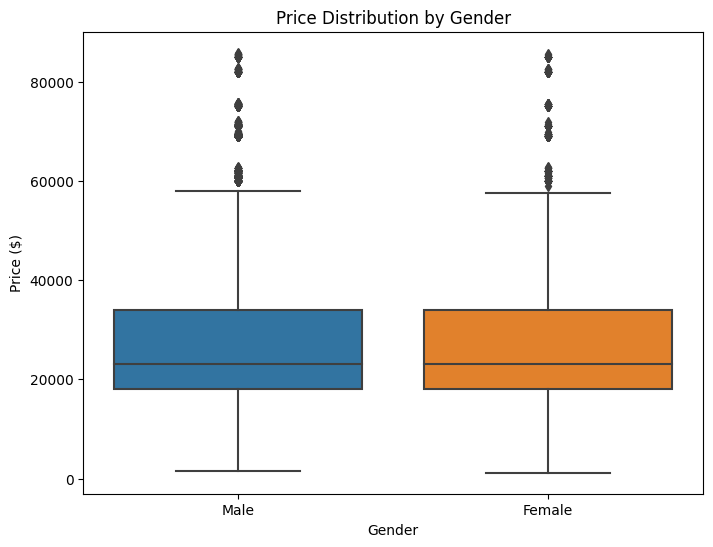

In [7]:


# 1. Price Distribution by Gender
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Price ($)', data=df)
plt.title('Price Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Price ($)')
plt.show()

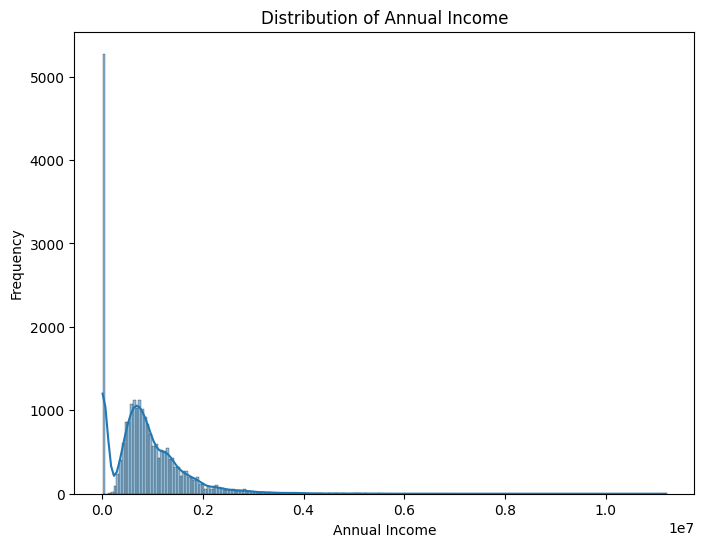

In [8]:
# 2. Annual Income Distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['Annual Income'], kde=True)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.show()

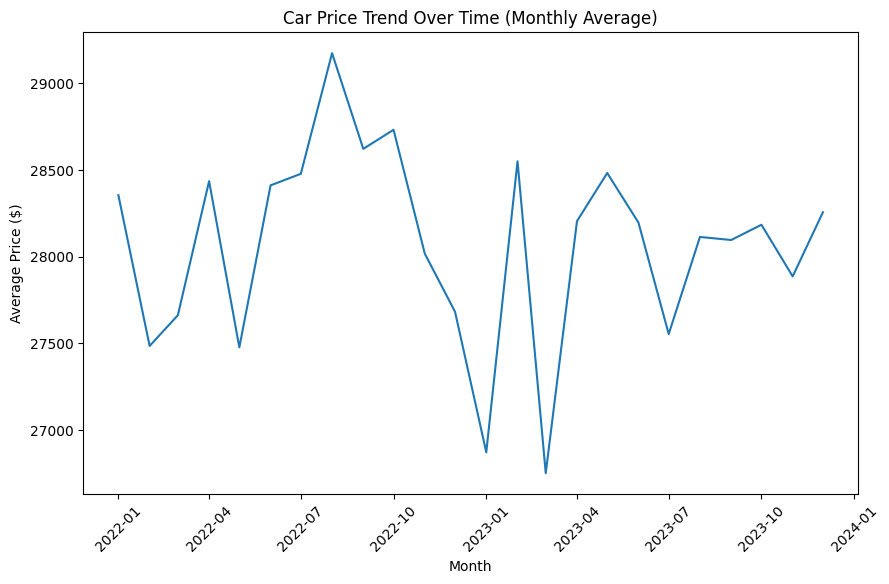

In [9]:
# Grouping data by month and calculating the average price for each month
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
monthly_price = df.groupby('Month')['Price ($)'].mean().reset_index()
monthly_price['Month'] = monthly_price['Month'].dt.to_timestamp()

# Code for the modified line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='Month', y='Price ($)', data=monthly_price)
plt.title('Car Price Trend Over Time (Monthly Average)')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()


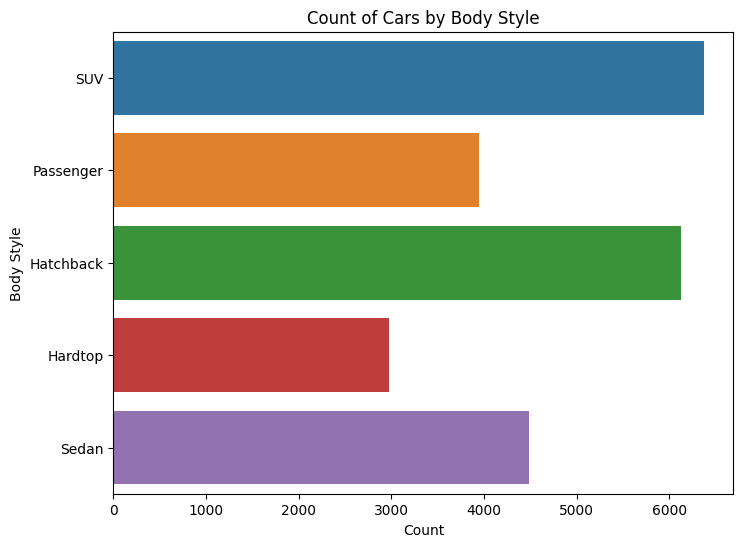

In [10]:
# 4. Count of Cars by Body Style
plt.figure(figsize=(8, 6))
sns.countplot(y='Body Style', data=df)
plt.title('Count of Cars by Body Style')
plt.xlabel('Count')
plt.ylabel('Body Style')
plt.show()

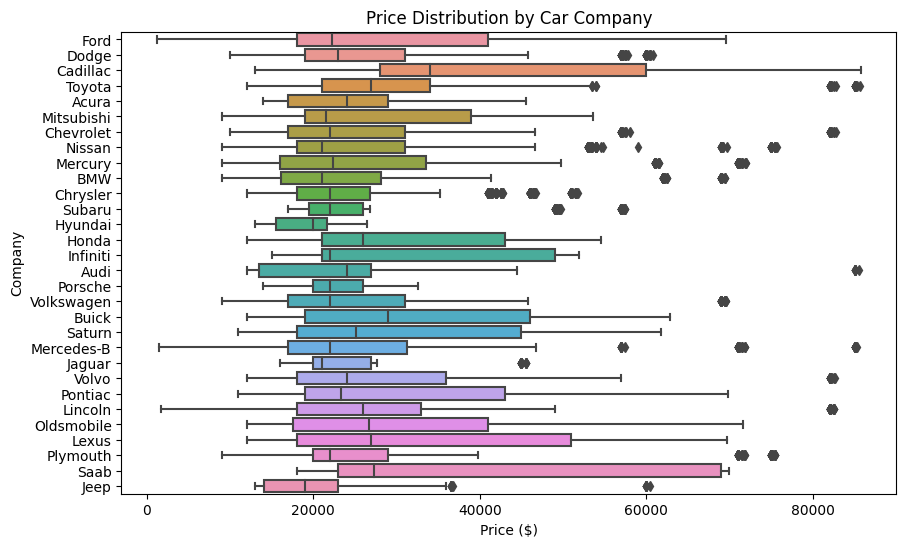

In [11]:
# 5. Price Distribution by Car Company
plt.figure(figsize=(10, 6))
sns.boxplot(x='Price ($)', y='Company', data=df)
plt.title('Price Distribution by Car Company')
plt.xlabel('Price ($)')
plt.ylabel('Company')
plt.show()

In [12]:
# Codificación one-hot para las columnas categóricas
categorical_cols = ['Gender', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Body Style', 'Dealer_Region']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Conversión de la fecha y el período a características numéricas
df_encoded['Year'] = df['Date'].dt.year
df_encoded['Month'] = df['Month'].dt.month

# Conservar las columnas numéricas existentes
numerical_cols = ['Car_id', 'Annual Income', 'Price ($)', 'Phone']
df_encoded[numerical_cols] = df[numerical_cols]

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Model'] = le.fit_transform(df['Model'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Company'] = le.fit_transform(df['Company'])

    

In [14]:
df.dtypes

Car_id                   object
Date             datetime64[ns]
Customer Name            object
Gender                    int64
Annual Income             int64
Dealer_Name              object
Company                   int64
Model                     int64
Engine                   object
Transmission             object
Color                    object
Price ($)                 int64
Dealer_No                object
Body Style               object
Phone                     int64
Dealer_Region            object
Month                 period[M]
dtype: object

In [15]:
df_pca = df[['Annual Income', 'Price ($)', 'Company', 'Model', 'Gender']]
df_pca.dtypes


Annual Income    int64
Price ($)        int64
Company          int64
Model            int64
Gender           int64
dtype: object

In [16]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Asumiendo que df_pca es tu DataFrame original preparado para PCA

# Aplicar PCA
pca = PCA(n_components=3)
reduced_data = pca.fit_transform(df_pca)

# Cambiar el DataFrame a las nuevas dimensiones PCA
df_pca_reduced = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])

# Aplicar K-Means para crear clusters
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(df_pca_reduced)

# Agregar la columna de clusters al DataFrame
df_pca_reduced['Cluster'] = clusters

# Crear el gráfico 3D de clustering
fig = px.scatter_3d(df_pca_reduced, x='PC1', y='PC2', z='PC3', color='Cluster', opacity=0.7, size_max=5, title='3D Clustering')
fig.show()


/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  # Importación para XGBoost
from catboost import CatBoostRegressor  # Importación para CatBoost
from lightgbm import LGBMRegressor  # Importación para LightGBM
from sklearn.neural_network import MLPRegressor  # Importación para MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('/kaggle/input/car-sales-report/Car Sales.xlsx - car_data.csv')

# Crear una lista de modelos
models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Lasso Regression', Lasso()),
    ('Decision Tree Regressor', DecisionTreeRegressor()),
    ('Random Forest Regressor', RandomForestRegressor()),
    ('Gradient Boosting Regressor', GradientBoostingRegressor()),
    ('SVR', SVR()),
    ('XGBoost Regressor', XGBRegressor()),  # Nuevo modelo XGBoost
    ('CatBoost Regressor', CatBoostRegressor(verbose=False)),  # Nuevo modelo CatBoost
    ('LightGBM Regressor', LGBMRegressor()),  # Nuevo modelo LightGBM
    ('MLP Regressor', MLPRegressor())  # Nuevo modelo MLPRegressor
]

# Resto del código...


# Codificar las columnas categóricas con Label Encoding
label_encoder = LabelEncoder()
categorical_cols = ['Gender', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Body Style', 'Dealer_Region']
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

# Extraer características relevantes y el objetivo
X = df[['Gender', 'Model', 'Engine', 'Transmission', 'Company', 'Color', 'Body Style', 'Dealer_Region']]

# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=3)  # Ajusta el número de componentes según tu elección
X_pca = pca.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba

y = df['Price ($)']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)



# Entrenar y evaluar cada modelo en el ciclo for
for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'Model: {model_name}')
    print(f'Mean Absolute Error (MAE): {mae}')
    print(f'R-squared (R^2): {r2}')
    print('-' * 40)


Model: Linear Regression
Mean Absolute Error (MAE): 11140.03163853532
R-squared (R^2): 0.004835799757272441
----------------------------------------
Model: Ridge Regression
Mean Absolute Error (MAE): 11140.031651851055
R-squared (R^2): 0.004835796869723574
----------------------------------------
Model: Lasso Regression
Mean Absolute Error (MAE): 11140.0395557
R-squared (R^2): 0.004834048452911688
----------------------------------------
Model: Decision Tree Regressor
Mean Absolute Error (MAE): 4503.445359703839
R-squared (R^2): 0.606198103741856
----------------------------------------
Model: Random Forest Regressor
Mean Absolute Error (MAE): 4487.754273441379
R-squared (R^2): 0.6382763157580379
----------------------------------------
Model: Gradient Boosting Regressor
Mean Absolute Error (MAE): 9429.607197244934
R-squared (R^2): 0.27307453794407366
----------------------------------------
Model: SVR
Mean Absolute Error (MAE): 10263.131467780468
R-squared (R^2): -0.10343981257640444


/opt/conda/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.



# Busqueda de hiperparametros Optuna

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score
import optuna
from xgboost import XGBRegressor  # Importación para XGBoost


# Aplicar PCA para reducción de dimensionalidad
pca = PCA(n_components=5)  # Ajusta el número de componentes según tu elección
X_pca = pca.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Función objetivo para Optuna
def objective(trial):
    # Definir los hiperparámetros a optimizar
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 5, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1)
    min_child_weight = trial.suggest_float('min_child_weight', 1, 5)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)

    # Inicializar y entrenar el modelo con los hiperparámetros sugeridos
    model = CatBoostRegressor(
    iterations=n_estimators,  # Número de iteraciones (equivalente a n_estimators en otros algoritmos)
    depth=max_depth,  # Profundidad máxima de los árboles
    learning_rate=learning_rate,  # Tasa de aprendizaje
    subsample=subsample,  # Proporción de muestras a utilizar para entrenar cada árbol
    colsample_bylevel=colsample_bytree,  # Proporción de características a utilizar para entrenar cada árbol
    random_state=42,  # Semilla aleatoria para reproducibilidad
    verbose=0  # Para deshabilitar los mensajes de registro de CatBoost
    )


    model.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Calcular el Mean Absolute Error (MAE)
    mae = mean_absolute_error(y_test, y_pred)
    return mae

# Crear un estudio Optuna y ejecutar la optimización
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Obtener los mejores hiperparámetros
best_params = study.best_params
print(f"Mejores hiperparámetros encontrados: {best_params}")


"""Mejores hiperparámetros XGBOOST  encontrados: 
{'n_estimators': 343, 'max_depth': 19, 'learning_rate': 0.022426191654851664, 
'min_child_weight': 1.0947563477821456, 'subsample': 0.9785566435758496, 
'colsample_bytree': 0.8824533599945352}"""

[I 2024-01-21 05:29:53,379] A new study created in memory with name: no-name-0e2aac25-bc01-4341-903c-0ba09bd22985
[I 2024-01-21 05:29:54,727] Trial 0 finished with value: 7210.623508923737 and parameters: {'n_estimators': 280, 'max_depth': 7, 'learning_rate': 0.05189302959719954, 'min_child_weight': 4.340689960675897, 'subsample': 0.9617215238348613, 'colsample_bytree': 0.6889101931064999}. Best is trial 0 with value: 7210.623508923737.
[I 2024-01-21 05:29:55,216] Trial 1 finished with value: 9110.066104196467 and parameters: {'n_estimators': 101, 'max_depth': 6, 'learning_rate': 0.05430260231106882, 'min_child_weight': 3.794096914967632, 'subsample': 0.9947519697266196, 'colsample_bytree': 0.8263541443225958}. Best is trial 0 with value: 7210.623508923737.
[I 2024-01-21 05:29:55,901] Trial 2 finished with value: 9347.295178610953 and parameters: {'n_estimators': 198, 'max_depth': 5, 'learning_rate': 0.03335445226362648, 'min_child_weight': 3.807369820364439, 'subsample': 0.86121933345

Mejores hiperparámetros encontrados: {'n_estimators': 489, 'max_depth': 10, 'learning_rate': 0.0975751939629909, 'min_child_weight': 1.4146144274488832, 'subsample': 0.9983795637332328, 'colsample_bytree': 0.7568812875821768}


"Mejores hiperparámetros XGBOOST  encontrados: \n{'n_estimators': 343, 'max_depth': 19, 'learning_rate': 0.022426191654851664, \n'min_child_weight': 1.0947563477821456, 'subsample': 0.9785566435758496, \n'colsample_bytree': 0.8824533599945352}"